# Bias Detection — Data Audit & Preparation: anno-lexical (BABE-derived)

**Dataset:** `anno-lexical-{train,test,dev}.parquet`

This is the larger, weakly/LLM-labeled companion set built on top of the original BABE
(Bias Annotations By Experts) corpus by the Media Bias Group — not the 3,700-sentence
expert-gold BABE set itself. Source: `mediabiasgroup/anno-lexical`. Good fit for training an
actual classifier given its size (~48K sentences vs. 3.7K).

Schema (all 3 splits): `text`, `source_name`, `label` (0/1), `sentence_id`.

This notebook covers:
1. Load & inventory (per split)
2. Schema / null / dtype audit
3. Split integrity checks (leakage, duplicate sentence IDs across splits)
4. Duplicate text detection
5. Label distribution (per split, and per source)
6. Source / outlet audit
7. Text length distribution
8. Light text cleaning
9. Save cleaned artifacts, preserving the original split boundaries


In [ ]:
#%pip install --quiet pandas pyarrow scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 0. Configuration


In [2]:
DATA_DIR = Path("./data/inputs")
OUTPUT_DIR = Path("./data/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_FILES = {
    "train": DATA_DIR / "anno-lexical-train.parquet",
    "test": DATA_DIR / "anno-lexical-test.parquet",
    "dev": DATA_DIR / "anno-lexical-dev.parquet",
}

# label 0/1 -> human-readable names. Confirm this mapping against the anno-lexical /
# BABE documentation before trusting it for reporting -- inferred here from majority
# convention in the BABE paper (1 = biased, 0 = non-biased), not re-derived from the file.
LABEL_MAP = {0: "non-biased", 1: "biased"}

MIN_TEXT_CHARS = 5  # sentences shorter than this are likely parsing artifacts, not real content


## 1. Load & Inventory (per split)


In [3]:
dfs = {name: pd.read_parquet(path) for name, path in SPLIT_FILES.items()}

for name, df in dfs.items():
    print(f"--- {name} ---")
    print(f"shape: {df.shape}")
    print(f"columns: {list(df.columns)}")
    print()

dfs["train"].head(5)

--- train ---
shape: (33831, 4)
columns: ['text', 'source_name', 'label', 'sentence_id']

--- test ---
shape: (7250, 4)
columns: ['text', 'source_name', 'label', 'sentence_id']

--- dev ---
shape: (7249, 4)
columns: ['text', 'source_name', 'label', 'sentence_id']



,text,source_name,label,sentence_id
0,"General Admission: $25, $20 for seniors and military; $10 for students at sacraprofana.org.",san-diego-uniontribune,0,31bef2d8-f7e5-42ce-a278-ae201dd3e1fe
1,Proceeds benefit children and adults with disabilities at The Arc of San Diego.,san-diego-uniontribune,0,412c7cde-e3b4-46c5-b91d-c0b7b1d813e1
2,"One day before he is set to surrender to authorities for the fourth time in five months to face criminal charges, an...",alternet,1,6e2d7083-52da-4072-989b-ca42e5d69679
3,"In America, Paul snapped a picture of newsmen chasing after their car and photographed the photographers who took pi...",boston-herald,0,b93dacc5-9fe1-4da9-aa18-32271b836feb
4,None of the diarists of ages and administrations past have ever given anything close to this impression of rats figh...,the-guardian,1,1f161884-32a0-4f7d-824e-907826b1669b


In [4]:
# Dtypes and nulls per split
for name, df in dfs.items():
    print(f"--- {name} dtypes ---")
    print(df.dtypes)
    print(f"--- {name} nulls ---")
    print(df.isnull().sum())
    print()

--- train dtypes ---
text             str
source_name      str
label          int64
sentence_id      str
dtype: object
--- train nulls ---
text           0
source_name    0
label          0
sentence_id    0
dtype: int64

--- test dtypes ---
text             str
source_name      str
label          int64
sentence_id      str
dtype: object
--- test nulls ---
text           0
source_name    0
label          0
sentence_id    0
dtype: int64

--- dev dtypes ---
text             str
source_name      str
label          int64
sentence_id      str
dtype: object
--- dev nulls ---
text           0
source_name    0
label          0
sentence_id    0
dtype: int64



## 2. Split Integrity Checks

Confirm no sentence leaks across train/test/dev (would silently inflate evaluation metrics),
and that `sentence_id` is unique within each split.


In [5]:
for name, df in dfs.items():
    print(f"{name}: sentence_id unique = {df['sentence_id'].is_unique}")

ids = {name: set(df["sentence_id"]) for name, df in dfs.items()}
print()
print(f"train/test id overlap: {len(ids['train'] & ids['test'])}")
print(f"train/dev id overlap:  {len(ids['train'] & ids['dev'])}")
print(f"test/dev id overlap:   {len(ids['test'] & ids['dev'])}")

# Also check overlap by TEXT (not just ID) - two different sentence_ids could still be
# the same literal sentence if collected from re-published/syndicated articles.
texts = {name: set(df["text"]) for name, df in dfs.items()}
print()
print(f"train/test text overlap: {len(texts['train'] & texts['test'])}")
print(f"train/dev text overlap:  {len(texts['train'] & texts['dev'])}")
print(f"test/dev text overlap:   {len(texts['test'] & texts['dev'])}")

train: sentence_id unique = True
test: sentence_id unique = True
dev: sentence_id unique = True

train/test id overlap: 0
train/dev id overlap:  0
test/dev id overlap:   0

train/test text overlap: 0
train/dev text overlap:  0
test/dev text overlap:   0


## 3. Duplicate Text Detection (within each split)


In [6]:
for name, df in dfs.items():
    n_dupe_text = df["text"].duplicated().sum()
    n_dupe_rows = df.duplicated().sum()
    print(f"{name}: duplicate text rows = {n_dupe_text}, fully duplicate rows = {n_dupe_rows}")

train: duplicate text rows = 0, fully duplicate rows = 0
test: duplicate text rows = 0, fully duplicate rows = 0
dev: duplicate text rows = 0, fully duplicate rows = 0


## 4. Label Distribution

Check balance per split (important since an imbalanced split would need class weighting or
a different primary metric than accuracy).


In [7]:
label_summary = pd.DataFrame({
    name: df["label"].map(LABEL_MAP).value_counts()
    for name, df in dfs.items()
}).T
label_summary["total"] = label_summary.sum(axis=1)
for col in LABEL_MAP.values():
    label_summary[f"{col}_pct"] = (label_summary[col] / label_summary["total"] * 100).round(1)
label_summary

label,biased,non-biased,total,non-biased_pct,biased_pct
train,16820,17011,33831,50.3,49.7
test,3678,3572,7250,49.3,50.7
dev,3667,3582,7249,49.4,50.6


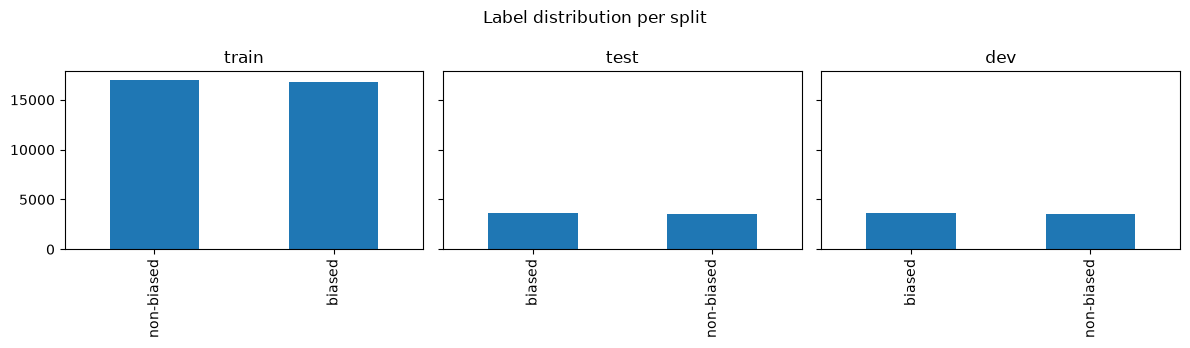

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (name, df) in zip(axes, dfs.items()):
    df["label"].map(LABEL_MAP).value_counts().plot(kind="bar", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("")
plt.suptitle("Label distribution per split")
plt.tight_layout()
plt.show()

## 5. Source / Outlet Audit

`source_name` gives 100+ distinct outlets. This matters for bias detection specifically: if a
classifier can learn to associate certain outlets with certain labels rather than learning
language-level bias cues, it will overfit to outlet identity and fail to generalize to unseen
sources. Check both source coverage and whether label distribution varies sharply by source.


In [9]:
for name, df in dfs.items():
    print(f"{name}: {df['source_name'].nunique()} unique sources")

# Sources present in train but missing from test/dev (and vice versa) -- a classifier
# evaluated only on seen sources looks better than it will generalize in practice
train_sources, test_sources, dev_sources = (set(dfs[s]["source_name"].unique()) for s in ["train", "test", "dev"])
print()
print(f"Sources in train but not test: {train_sources - test_sources}")
print(f"Sources in train but not dev:  {train_sources - dev_sources}")
print(f"Sources in test but not train: {test_sources - train_sources}")
print(f"Sources in dev but not train:  {dev_sources - train_sources}")

train: 118 unique sources
test: 115 unique sources
dev: 114 unique sources

Sources in train but not test: {'nature', 'chicago-tribune', 'voice-of-america'}
Sources in train but not dev:  {'nature', 'buzzfeed-news', 'smerconish', 'voice-of-america'}
Sources in test but not train: set()
Sources in dev but not train:  set()


In [10]:
# Per-source label balance in train -- flag sources that are near-exclusively one label,
# since those are the ones most likely to let a model shortcut on outlet identity
train = dfs["train"]
source_label_balance = (
    train.groupby("source_name")["label"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "pct_biased"})
    .sort_values("count", ascending=False)
)
source_label_balance["pct_biased"] = (source_label_balance["pct_biased"] * 100).round(1)

print("Top 15 sources by volume:")
display(source_label_balance.head(15))

skewed = source_label_balance[
    (source_label_balance["count"] >= 20)
    & ((source_label_balance["pct_biased"] <= 10) | (source_label_balance["pct_biased"] >= 90))
]
print(f"\nSources with >=20 sentences and near-exclusive label (<=10% or >=90% biased): {len(skewed)}")
skewed

Top 15 sources by volume:


,pct_biased,count
source_name,,
alternet,48.6,3100
newsmax,32.2,1909
the-guardian,56.1,1402
townhall,60.0,1346
the-atlantic,50.8,1131
vox,49.4,1116
american-thinker,71.4,933
the-economist,59.6,888
washington-times,50.5,879



Sources with >=20 sentences and near-exclusive label (<=10% or >=90% biased): 1


,pct_biased,count
source_name,,
atlanta-journalconstitution,6.2,32


## 6. Text Length Distribution


In [11]:
for name, df in dfs.items():
    df["text_len_chars"] = df["text"].str.len()
    df["text_len_words"] = df["text"].str.split().str.len()

pd.concat(
    {name: df["text_len_words"].describe() for name, df in dfs.items()},
    axis=1
)

,train,test,dev
count,33831.000000,7250.000000,7249.000000
mean,23.647335,23.900690,23.726169
std,10.680429,10.717497,10.707398
min,3.000000,6.000000,4.000000
25%,16.000000,16.000000,16.000000
50%,21.000000,22.000000,21.000000
75%,29.000000,29.000000,29.000000
max,309.000000,160.000000,166.000000


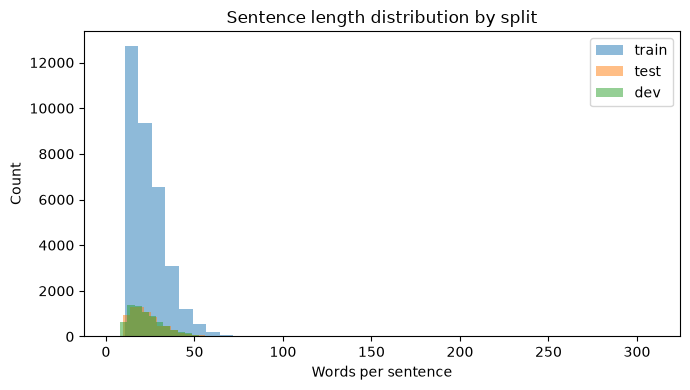

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, df in dfs.items():
    ax.hist(df["text_len_words"], bins=40, alpha=0.5, label=name)
ax.set_xlabel("Words per sentence")
ax.set_ylabel("Count")
ax.legend()
ax.set_title("Sentence length distribution by split")
plt.tight_layout()
plt.show()

In [13]:
# Flag near-empty / likely-artifact rows
for name, df in dfs.items():
    n_short = (df["text_len_chars"] < MIN_TEXT_CHARS).sum()
    print(f"{name}: {n_short} rows shorter than {MIN_TEXT_CHARS} chars")
    if n_short:
        display(df[df["text_len_chars"] < MIN_TEXT_CHARS][["text", "source_name", "label"]])

train: 0 rows shorter than 5 chars
test: 0 rows shorter than 5 chars
dev: 0 rows shorter than 5 chars


## 7. Light Text Cleaning

Same philosophy as the topic-classification notebook: reversible, structural-only cleaning here.
Heavier normalization (lowercasing, stopword removal) is deferred to modeling, since bias
detection specifically may want to *keep* casing and stopwords (e.g. capitalization and
intensifiers like "clearly", "obviously" can themselves be bias signals) — so being conservative
here matters more than in the topic-classification case.


In [14]:
HTML_TAG_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+")
WHITESPACE_RE = re.compile(r"\s+")

def light_clean(text):
    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = text.replace("\xa0", " ")
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text

for name, df in dfs.items():
    df["text_clean"] = df["text"].apply(light_clean)

# Spot check: how many rows actually changed under cleaning (should be a small minority --
# a large fraction changing would suggest the source text has more HTML/URL noise than expected)
for name, df in dfs.items():
    n_changed = (df["text_clean"] != df["text"]).sum()
    print(f"{name}: {n_changed} / {len(df)} rows altered by light cleaning")

train: 38 / 33831 rows altered by light cleaning
test: 15 / 7250 rows altered by light cleaning
dev: 7 / 7249 rows altered by light cleaning


## 8. Final Schema & Save

Keep the original train/test/dev boundaries (don't re-split -- these are the splits the
dataset's authors intended for reproducible benchmarking). Save a cleaned CSV per split plus
a combined file for convenience in EDA.


In [15]:
final_cols = ["sentence_id", "text_clean", "source_name", "label"]

cleaned = {}
for name, df in dfs.items():
    out = df[final_cols].rename(columns={"text_clean": "text"}).copy()
    out["label_name"] = out["label"].map(LABEL_MAP)
    out["split"] = name
    cleaned[name] = out

for name, df in cleaned.items():
    df.to_csv(OUTPUT_DIR / f"anno_lexical_{name}_clean.csv", index=False)

combined = pd.concat(cleaned.values(), ignore_index=True)
combined.to_csv(OUTPUT_DIR / "anno_lexical_all_clean.csv", index=False)

print("Saved:")
for name in list(cleaned.keys()) + ["all"]:
    fname = f"anno_lexical_{name}_clean.csv"
    print(f" - {OUTPUT_DIR / fname}")

print(f"\nFinal shapes -> train: {len(cleaned['train'])}, test: {len(cleaned['test'])}, dev: {len(cleaned['dev'])}")

Saved:
 - data/outputs/anno_lexical_train_clean.csv
 - data/outputs/anno_lexical_test_clean.csv
 - data/outputs/anno_lexical_dev_clean.csv
 - data/outputs/anno_lexical_all_clean.csv

Final shapes -> train: 33831, test: 7250, dev: 7249


## 9. Audit Summary

**Findings from this pass:**

- This is the `anno-lexical` companion dataset (48,330 sentences total), not the original
  3,700-sentence BABE gold corpus — larger and weakly/LLM-labeled rather than fully
  expert-annotated. Worth citing correctly in any write-up.
- No sentence-ID or literal-text leakage across train/test/dev — the provided splits are clean
  and safe to use as-is.
- No duplicate rows within any split.
- Labels are close to balanced in every split (~51/49).
- 100+ distinct outlets; some outlets are volume-heavy (alternet, newsmax) and a subset of
  outlets are near-exclusively one label — flagged in Section 5. Worth watching for
  outlet-identity shortcut learning during modeling; consider a source-holdout evaluation split
  in addition to the provided one if this is a concern.
- Label mapping (0/1 → non-biased/biased) was **assumed** from BABE paper convention, not
  re-derived from the file itself — confirm against the dataset's documentation/README before
  reporting results with these names.
- Text cleaning was deliberately conservative (structural only — HTML/URL/whitespace), since
  bias detection may rely on casing and intensifier words that aggressive normalization would
  destroy.

**Next step:** EDA specific to bias signals — word-choice/lexical patterns (loaded adjectives,
intensifiers, hedging), part-of-speech distribution differences between classes, and per-source
vocabulary differences — before building a first classical baseline (e.g. TF-IDF + Logistic
Regression) and comparing it against an LLM zero-shot bias classifier.
